In [ ]:
import torch
import torch.nn as nn
from transformers import CLIPVisionModelWithProjection, ViTForImageClassification, AutoModelForCausalLM
from transformers import AutoModel, AutoTokenizer, LlamaForCausalLM

import sys, os, json, math
from tqdm import tqdm
import numpy as np

from scipy.stats import pearsonr, spearmanr
from scipy.stats import kurtosis

import re
import matplotlib.pyplot as plt
std = 0.012528747320175171

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM
from tqdm import tqdm
from scipy.stats import kurtosis
import matplotlib.pyplot as plt
import numpy as np

# --- 1. 스타일 설정 (깔끔한 그래프를 위해) ---
plt.style.use('seaborn-v0_8-whitegrid') # 또는 'ggplot', 'bmh' 등 사용 가능
plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 20,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 16,
    'figure.titlesize': 22
})


# --- 2. 유틸리티 함수 (기존 유지) ---
def get_blocks(model):
    model_class = model.__class__.__name__
    if model_class in ("LlamaForCausalLM", "Qwen2ForCausalLM", "MistralForCausalLM"):
        return model.model.layers
    elif model_class == "LlavaLlamaForCausalLM":
        return model.model.layers
    else:
        raise ValueError(f"Unsupported model class: {model_class}")

def get_named_linears(module):
    return {name: m for name, m in module.named_modules() if isinstance(m, nn.Linear)}

def get_model_weight_stats(model):
    stats = {'std': {}, 'kurt': {}, 'kurt_std0': {}, 'kurt_std1': {}, 'kurt_std01': {}, 'kurt_std10': {}}
    layer_name_map = {
        'self_attn.q_proj': 'q', 'self_attn.k_proj': 'k', 'self_attn.v_proj': 'v',
        'self_attn.o_proj': 'o', 'mlp.up_proj': 'up', 'mlp.gate_proj': 'gate',
        'mlp.down_proj': 'down',
    }
    
    try:
        layers = get_blocks(model)
        num_layers = len(layers)
    except (ValueError, AttributeError) as e:
        print(f"Could not get layers: {e}")
        return stats

    eps = 1e-12
    print(f"Calculating stats for {num_layers} layers...")
    for i in tqdm(range(num_layers), desc="Processing Layers"):
        named_linears = get_named_linears(layers[i])
        for n, m in named_linears.items():
            if n in layer_name_map:
                # .float()로 변환하여 정밀도 확보
                w = m.weight.data.detach().float()
                key = f'{i}_{layer_name_map[n]}.pt'

                stats['std'][key] = w.std().item()
                stats['kurt'][key] = kurtosis(w.flatten().cpu().numpy(), fisher=True)

                std0 = w.std(dim=0, keepdim=True).clamp_min(eps)
                std1 = w.std(dim=1, keepdim=True).clamp_min(eps)

                w_norm0 = w / std0
                stats['kurt_std0'][key] = kurtosis(w_norm0.flatten().cpu().numpy(), fisher=True)

                w_norm1 = w / std1
                stats['kurt_std1'][key] = kurtosis(w_norm1.flatten().cpu().numpy(), fisher=True)
                
                w_norm01 = w_norm0 / std1
                stats['kurt_std01'][key] = kurtosis(w_norm01.flatten().cpu().numpy(), fisher=True)

                w_norm10 = w_norm1 / std0
                stats['kurt_std10'][key] = kurtosis(w_norm10.flatten().cpu().numpy(), fisher=True)
                
                # print(
                #     f"{key} kurt={stats['kurt'][key]:.6f} "
                #     f"kurt_std0={stats['kurt_std0'][key]:.6f} "
                #     f"kurt_std1={stats['kurt_std1'][key]:.6f} "
                #     f"kurt_std01={stats['kurt_std01'][key]:.6f} "
                #     f"kurt_std10={stats['kurt_std10'][key]:.6f} "
                # )
    return stats
# --- 3. 메인 실행 및 데이터 로드 ---
# (이미 통계 데이터가 있다면 이 부분은 건너뛰고 all_stats를 그대로 사용하셔도 됩니다)

model_path ="/home/jgryu/workspace/weight_compression/Wparam_dataset/hf_model/meta-llama--Meta-Llama-3-8B"
model_name = "Llama-3-8B"

print(f"--- Loading {model_name} ---")
try:
    model = AutoModelForCausalLM.from_pretrained(
        model_path,
        torch_dtype='auto',
        low_cpu_mem_usage=True,
        device_map='cuda'
    )
    stats = get_model_weight_stats(model)
    
    # 시각화 함수에 전달하기 편하게 구조 맞춤
    all_stats = {model_name: stats}

except Exception as e:
    print(f"Error: {e}")
    stats = None
finally:
    if 'model' in locals(): del model
    torch.cuda.empty_cache()


In [ ]:
import torch
import pickle

# # [저장] 계산이 끝난 직후 실행 (최초 1회)
# # all_stats 딕셔너리가 메모리에 있다고 가정
# with open('./llama3_8b_stats.pkl', 'wb') as f:
#     pickle.dump(all_stats, f)
# print("Stats saved successfully.")

# ------------------------------------------------

# [로드] 시각화 코드를 수정할 때마다 이 부분만 실행
with open('./llama3_8b_stats.pkl', 'rb') as f:
    loaded_stats = pickle.load(f)
print("Stats loaded successfully.")

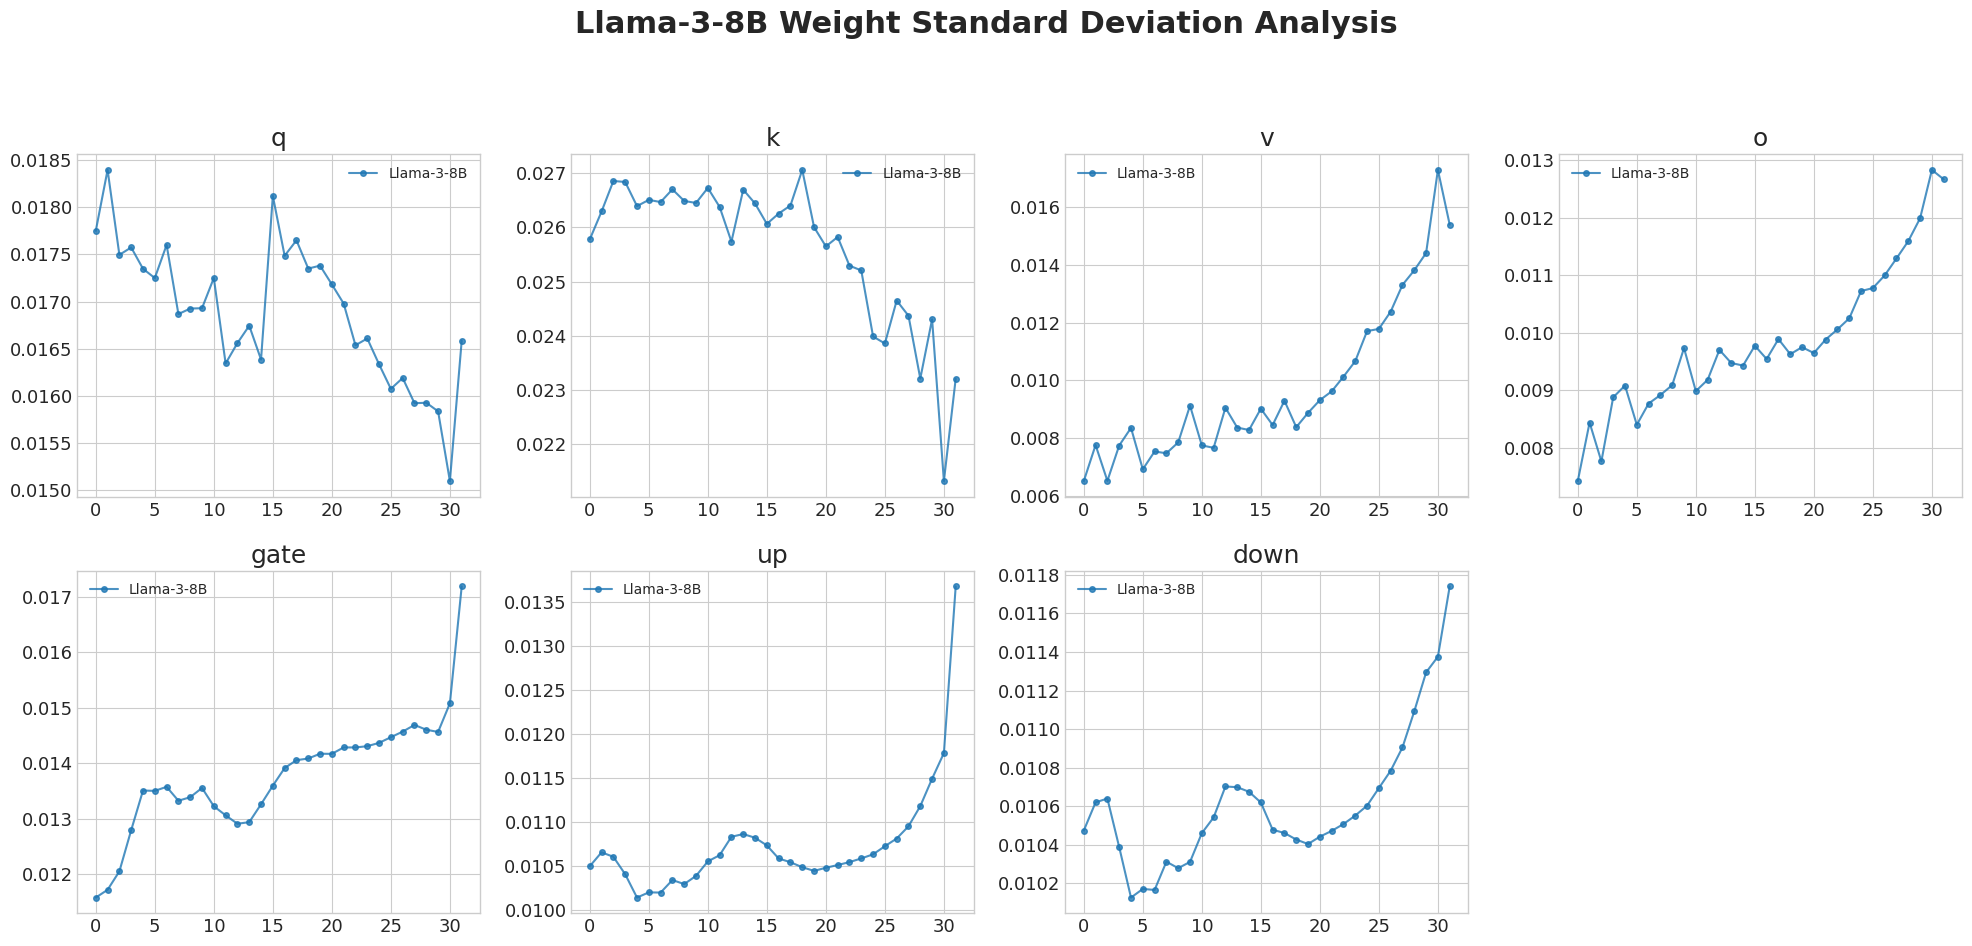

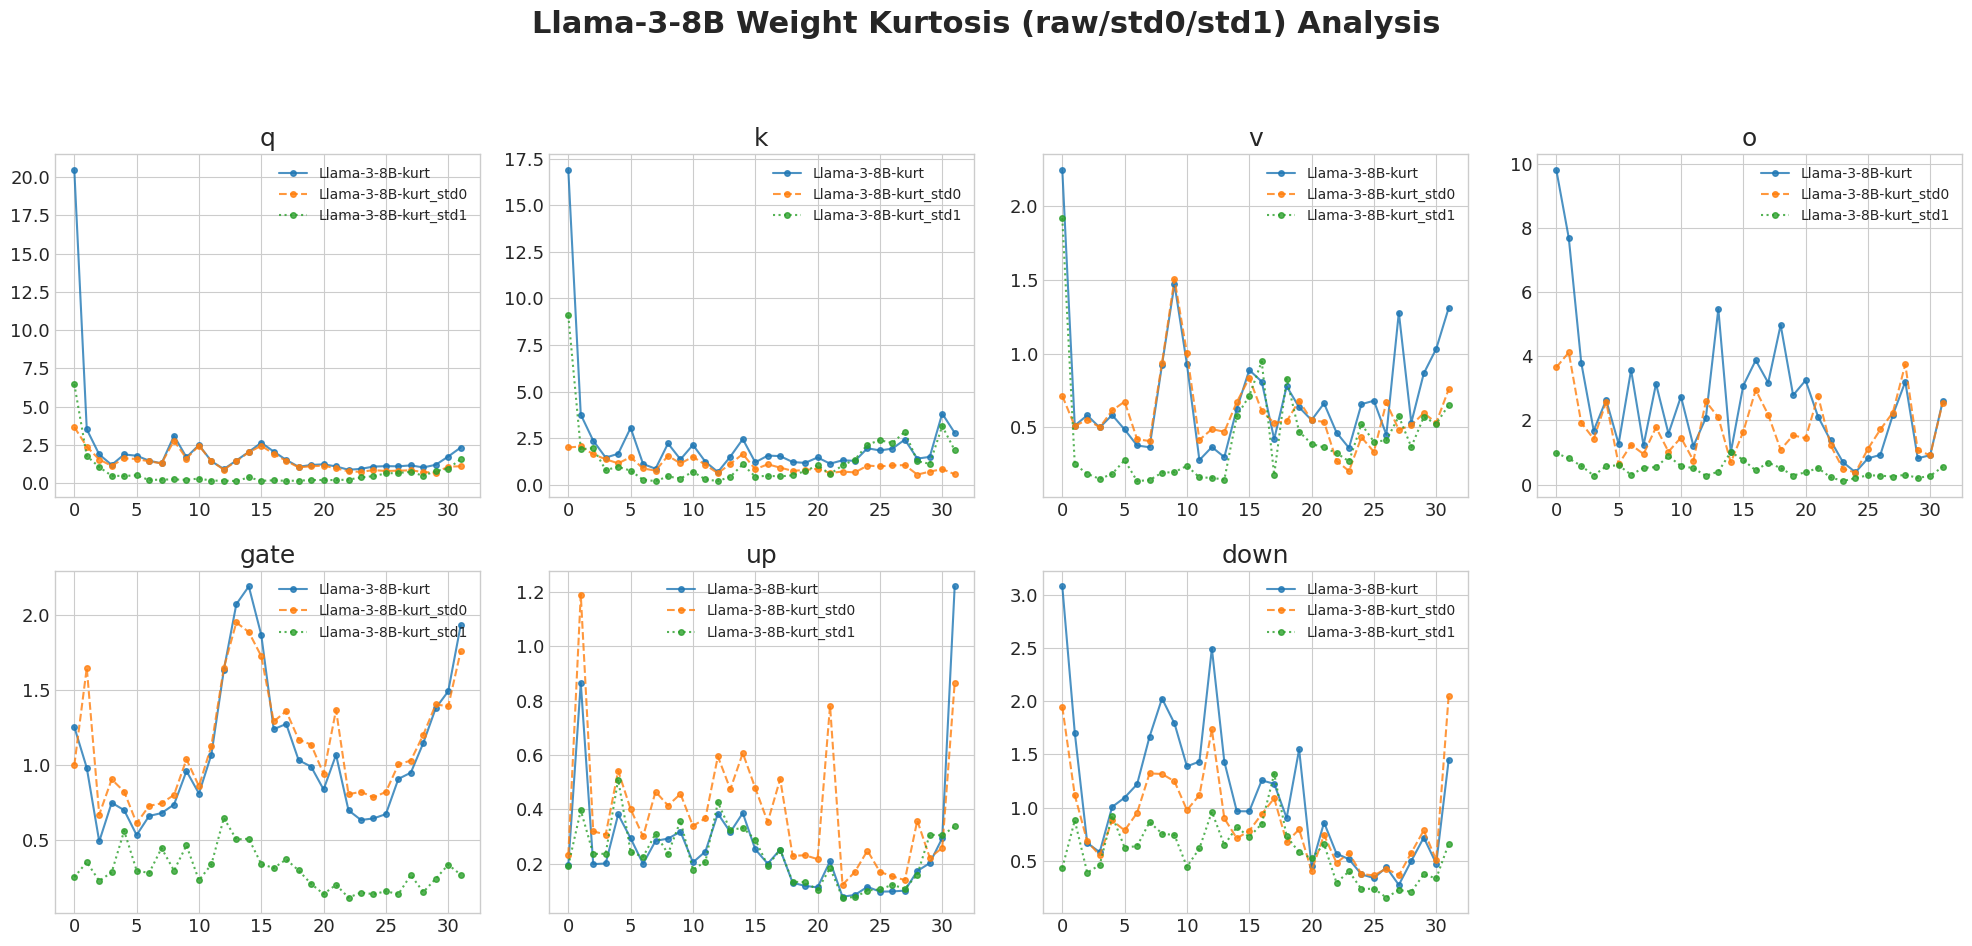

In [4]:
def plot_layer_stats(all_stats, metric_type='std'):
    """
    metric_type: 'std' or 'kurt'
    """
    import matplotlib.pyplot as plt

    if not all_stats:
        return

    # Layer order: Attention -> MLP
    lyr_list = ['q', 'k', 'v', 'o', 'gate', 'up', 'down']

    # 2x4 grid (last one unused)
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    if metric_type == 'std':
        metric_keys = ['std']
        metric_labels = ['std']
        metric_title = 'Standard Deviation'
    elif metric_type == 'kurt':
        metric_keys = ['kurt', 'kurt_std0', 'kurt_std1']
        metric_labels = ['kurt', 'kurt_std0', 'kurt_std1']
        metric_title = 'Kurtosis (raw/std0/std1)'
    else:
        metric_keys = [metric_type]
        metric_labels = [metric_type]
        metric_title = metric_type

    fig.suptitle(f'Llama-3-8B Weight {metric_title} Analysis', fontweight='bold')

    # 색을 metric마다 다르게! (한 plot-kurt 안에서 여러 metric)
    kurt_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']
    # m_name별 색이 아니라, metric별 색
    linestyles = ['-', '--', ':', '-.']

    for i, lyr_type in enumerate(lyr_list):
        ax = axes[i]

        for m_idx, (m_name, m_stats) in enumerate(all_stats.items()):
            for k_idx, metric_key in enumerate(metric_keys):
                data_map = m_stats.get(metric_key, {})
                if not data_map:
                    continue

                # Extract data in layer order
                layers_indices = []
                values = []

                filtered_keys = [k for k in data_map.keys() if f'_{lyr_type}.pt' in k]
                filtered_keys.sort(key=lambda x: int(x.split('_')[0]))

                for k in filtered_keys:
                    idx = int(k.split('_')[0])
                    layers_indices.append(idx)
                    values.append(data_map[k])

                if values:
                    # 여기서는 metric별로 색을 다르게 함 (특히 kurt)
                    if metric_type == 'kurt':
                        color = kurt_palette[k_idx % len(kurt_palette)]
                    else:
                        color = '#1f77b4'
                    label = (
                        f"{m_name}-{metric_labels[k_idx]}"
                        if len(metric_keys) > 1
                        else m_name
                    )
                    ax.plot(
                        layers_indices,
                        values,
                        marker='o',
                        markersize=4,
                        linewidth=1.5,
                        label=label,
                        color=color,
                        linestyle=linestyles[k_idx % len(linestyles)],
                        alpha=0.8
                    )
        ax.set_title(lyr_type)
        ax.grid(True)
        ax.legend(fontsize=10)

    # 깔끔하게 빈 축 숨김
    for j in range(len(lyr_list), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout(rect=[0, 0.03, 1, 0.94])  # suptitle 여백
    plt.show()

plot_layer_stats(all_stats, metric_type='std')
plot_layer_stats(all_stats, metric_type='kurt')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def plot_weight_heatmap(all_stats, model_name, metric_type='std'):
    """
    히트맵을 통해 모델 전체의 레이어(x축) vs 모듈(y축) 통계치를 시각화합니다.
    """
    if model_name not in all_stats:
        print("Model data not found.")
        return

    data_map = all_stats[model_name].get(metric_type, {})
    if not data_map:
        return

    # 1. 데이터 포맷팅 (Matrix 형태로 변환)
    # 모듈 순서 (위에서 아래로 표시될 순서)
    modules = ['q', 'k', 'v', 'o', 'gate', 'up', 'down']
    
    # 레이어 개수 자동 파악
    max_layer = max([int(k.split('_')[0]) for k in data_map.keys()]) + 1
    
    # 히트맵용 데이터 매트릭스 생성 (Row: Module, Col: Layer)
    heatmap_data = np.zeros((len(modules), max_layer))
    
    for i, mod in enumerate(modules):
        for layer_idx in range(max_layer):
            key = f'{layer_idx}_{mod}.pt'
            if key in data_map:
                heatmap_data[i, layer_idx] = data_map[key]
            else:
                heatmap_data[i, layer_idx] = np.nan # 데이터 없으면 빈칸

    # 2. 시각화
    plt.figure(figsize=(18, 6))
    
    metric_label = "Standard deviation" if metric_type == 'std' else "Kurtosis"
    
    # Seaborn Heatmap
    ax = sns.heatmap(
        heatmap_data, 
        annot=False,      # 칸 안에 숫자 표시 여부 (너무 많으니 False)
        fmt=".4f", 
        cmap="viridis",   # 색상 테마 (viridis, magma, coolwarm, RdBu_r)
        yticklabels=[m.upper() for m in modules], # Y축 라벨 대문자로
        xticklabels=2     # X축 라벨 간격 (2개마다 표시)
    )
    
    plt.title(f'{metric_label}', fontweight='bold')
    plt.xlabel('Layer depth')
    plt.ylabel('Layer type')
    
    # 레이어 방향으로 보기 편하게 X축 라벨 회전
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    
    # plt.title(f'[{model_name}] Weight {metric_label} Heatmap', fontsize=16, fontweight='bold')
    plt.savefig(f'./plot/{model_name}_{metric_label}_heatmap.pdf')
    plt.show()

# --- 실행 ---
# loaded_stats는 pickle로 불러온 데이터입니다.
plot_weight_heatmap(all_stats, "Llama-3-8B", metric_type='std')
plot_weight_heatmap(all_stats, "Llama-3-8B", metric_type='kurt')

In [ ]:
import glob
import json
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import numpy as np

# 스타일 설정
sns.set_theme(style="whitegrid")

data_records = []

# --- A. Lambda 데이터 로드 ---
lambda_path_list = [
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft'
]

print("--- Loading Lambda Data ---")
for path in lambda_path_list:
    if not os.path.exists(path): continue
    
    # zeroshot 제외한 json 파일들
    json_files = glob.glob(f'{path}/*.json')
    json_files = [f for f in json_files if 'zeroshot' not in f]
    
    for file_path in json_files:
        filename = os.path.basename(file_path)
        
        # 정규표현식으로 'lmbda' 뒤의 숫자 추출 (예: test_lmbda1000.json -> 1000)
        # 소수점도 처리 가능하게 (\d+(\.\d+)?) 패턴 사용
        match = re.search(r'lmbda([\d\.]+)', filename)
        if match:
            lambda_val = float(match.group(1))
        else:
            print(f"Skipping {filename}: 'lmbda' value not found")
            continue

        try:
            with open(file_path, 'r') as f:
                content = json.load(f)
                for key, val in content.items():
                    if key.endswith('.pt'):
                        record = {
                            'source': 'Lambda',
                            'lambda_val': lambda_val,      # 추출한 람다 값
                            'layer': key,
                            'module': key.split('_')[1].replace('.pt', ''),
                            'layer_idx': int(key.split('_')[0]),
                            'bpp_loss': val.get('bpp_loss'),
                            'mse': val.get('mse'),
                            'proxy_err':val.get('proxy_err')
                        }
                        data_records.append(record)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# --- B. QTiP 데이터 로드 ---
qtip_path_list = [
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results/qtip/llama3_8b/ft1' 
]

print("\n--- Loading QTiP Data ---")
for path in qtip_path_list:
    if not os.path.exists(path): continue
    
    # 2bit, 3bit 등 패턴 찾기
    json_files = glob.glob(f'{path}/*bit_MSE_data.json')
    
    for file_path in json_files:
        filename = os.path.basename(file_path)
        
        # 'bit' 앞의 숫자 추출 (예: 2bit_MSE.json -> 2.0)
        try:
            target_bit = float(filename.split('bit')[0])
        except:
            continue
            
        try:
            with open(file_path, 'r') as f:
                content = json.load(f)
                for key, val in content.items():
                    if key.endswith('.pt'):
                        record = {
                            'source': 'QTiP',
                            'target_bit': target_bit,     # 추출한 비트 값
                            'layer': key,
                            'module': key.split('_')[1].replace('.pt', ''),
                            'layer_idx': int(key.split('_')[0]),
                            'bpp_loss': target_bit,       # QTiP은 Target Bit가 BPP
                            'mse': val.get('mse'),
                            'proxy_err':val.get('proxy_err')
                        }
                        data_records.append(record)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# DataFrame 생성
df = pd.DataFrame(data_records)


In [ ]:
def draw_heatmap(data, value_col, title, log_scale=False, cmap='viridis'):
    """
    특정 DataFrame 데이터(data)를 받아 히트맵을 그리는 헬퍼 함수
    """
    module_order = ['q', 'k', 'v', 'o', 'gate', 'up', 'down']
    
    # 피벗 테이블 생성
    pivot_df = data.pivot_table(
        index='module', 
        columns='layer_idx', 
        values=value_col, 
        aggfunc='mean'
    )
    
    # 모듈 순서 정렬
    current_order = [m for m in module_order if m in pivot_df.index]
    pivot_df = pivot_df.reindex(current_order)
    
    plt.figure(figsize=(18, 6))
    
    # Log Scale 적용 여부
    norm = LogNorm() if log_scale else None
    fmt = ".1e" if log_scale else ".2f" # 로그면 지수표기, 선형이면 소수점
    
    sns.heatmap(
        pivot_df,
        annot=False,
        fmt=fmt,
        cmap=cmap,
        norm=norm,
        yticklabels=True
    )
    
    plt.rcParams.update({
        'font.size': 16,
        'axes.titlesize': 18,
        'axes.labelsize': 20,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'legend.fontsize': 16,
        'figure.titlesize': 22
    })
    
    scale_txt = "log_scale" if log_scale else ""
    plt.title(f'{title} {value_col.upper()} (Log scale)', fontweight='bold')
    plt.xlabel('Layer depth')
    plt.ylabel('Layer type')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'./plot/{title}_{value_col.upper()}_{scale_txt}.pdf')
    plt.show()

In [ ]:


if not df.empty:
    print("--- Filtering and Plotting specific cases ---")

    # 1. QTiP 4-bit MSE
    # (주의: target_bit가 float(4.0)일 수 있으므로 4와 비교)
    target_qtip = df[(df['source'] == 'QTiP') & (df['target_bit'] == 4)]
    
    if not target_qtip.empty:
        draw_heatmap(
            target_qtip, 
            value_col='mse', 
            title=f'[QTIP-4bit]', 
            log_scale=True, 
            cmap='plasma'
        )
    else:
        print("Warning: QTiP 4-bit data not found.")

    # 2. Lambda 300 MSE
    # (주의: lambda_val이 float(300.0)일 수 있음)
    target_lambda = df[(df['source'] == 'Lambda') & (df['lambda_val'] == 300)]
    
    if not target_lambda.empty:
        draw_heatmap(
            target_lambda, 
            value_col='mse', 
            title='[Lambda] λ=300', 
            log_scale=True, 
            cmap='plasma'
        )
    else:
        print("Warning: Lambda 300 data not found.")

else:
    print("No data loaded in DataFrame.")

In [ ]:
if not df.empty:
    
    # === A. QTiP 시각화 (Bit별 MSE & Proxy Loss) ===
    df_qtip = df[df['source'] == 'QTiP']
    
    if not df_qtip.empty:
        bits = sorted(df_qtip['target_bit'].unique())
        print(f"\n[QTiP Visualization] Found bits: {bits}")
        
        for bit in bits:
            subset = df_qtip[df_qtip['target_bit'] == bit]
            
            # 1. MSE Heatmap (Log Scale)
            draw_heatmap(
                subset, 
                value_col='mse', 
                title=f'[QTiP] Target Bit: {bit}', 
                log_scale=True, 
                cmap='plasma'
            )
            
            # 2. Proxy Error Heatmap (Log Scale) - 추가됨
            # 데이터가 모두 NaN이 아닌 경우에만 그리기 (QTiP은 없을 수도 있음)
            if subset['proxy_err'].notna().any():
                draw_heatmap(
                    subset, 
                    value_col='proxy_err', 
                    title=f'[QTiP] Target Bit: {bit} - Proxy Loss', 
                    log_scale=True, 
                    cmap='magma' 
                )

    # === B. Lambda 시각화 (Lambda별 MSE & BPP & Proxy Loss) ===
    df_lambda = df[df['source'] == 'Lambda']
    
    if not df_lambda.empty:
        lambdas = sorted(df_lambda['lambda_val'].unique())
        print(f"\n[Lambda Visualization] Found lambdas: {lambdas}")
        
        for lmbda in lambdas:
            subset = df_lambda[df_lambda['lambda_val'] == lmbda]
            
            # 1. MSE Heatmap (Log Scale)
            draw_heatmap(
                subset, 
                value_col='mse', 
                title=f'[Lambda] λ={lmbda}', 
                log_scale=True, 
                cmap='plasma'
            )
            
            # 2. Proxy Error Heatmap (Log Scale) - 추가됨
            draw_heatmap(
                subset, 
                value_col='proxy_err', 
                title=f'[Lambda] λ={lmbda} - Proxy Loss', 
                log_scale=True, 
                cmap='magma'
            )
            
            # 3. BPP Heatmap (Linear Scale)
            draw_heatmap(
                subset, 
                value_col='bpp_loss', 
                title=f'[Lambda] λ={lmbda}', 
                log_scale=False, 
                cmap='viridis'
            )

else:
    print("No data found to plot.")